In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')

In [ ]:
df = pd.read_csv("C:\\Users\\it24102555\\Desktop\\Lab 03\\student_data.csv")
display(df)

,StudentID,Gender,Age,Country,Lessons Completed,Quiz Score,Time Per Week,Result
0,S001,Male,20.0,India,25,78.5,10,Pass
1,S002,Female,22.0,USA,30,82.0,12,Pass
2,S003,Male,19.0,Sri Lanka,18,45.0,8,Fail
3,S004,Female,21.0,India,28,88.0,9,Pass
4,S005,Female,18.0,USA,15,35.0,5,Fail
5,S006,Male,NaN,Sri Lanka,10,25.0,4,Fail
6,S007,Male,24.0,India,32,90.0,14,Pass
7,S008,Female,23.0,USA,20,NaN,11,Pass
8,S009,Male,25.0,India,29,77.0,10,Pass
9,S010,Female,20.0,Sri Lanka,14,30.0,6,Fail


In [3]:
df.head(5)

,StudentID,Gender,Age,Country,Lessons Completed,Quiz Score,Time Per Week,Result
0,S001,Male,20.0,India,25,78.5,10,Pass
1,S002,Female,22.0,USA,30,82.0,12,Pass
2,S003,Male,19.0,Sri Lanka,18,45.0,8,Fail
3,S004,Female,21.0,India,28,88.0,9,Pass
4,S005,Female,18.0,USA,15,35.0,5,Fail


In [4]:
df.tail(5)

,StudentID,Gender,Age,Country,Lessons Completed,Quiz Score,Time Per Week,Result
15,S016,Female,24.0,India,18,40.0,6,Fail
16,S017,Male,21.0,Sri Lanka,20,65.0,8,Pass
17,S018,Female,26.0,India,27,84.0,9,Pass
18,S019,Male,22.0,India,35,95.0,15,Pass
19,S020,Female,20.0,Sri Lanka,12,50.0,5,Fail


In [5]:
print(list(df.columns))

['StudentID', 'Gender', 'Age', 'Country', 'Lessons Completed', 'Quiz Score', 'Time Per Week', 'Result']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          20 non-null     object 
 1   Gender             20 non-null     object 
 2   Age                18 non-null     float64
 3   Country            20 non-null     object 
 4   Lessons Completed  20 non-null     int64  
 5   Quiz Score         18 non-null     float64
 6   Time Per Week      20 non-null     int64  
 7   Result             20 non-null     object 
dtypes: float64(2), int64(2), object(4)
memory usage: 1.4+ KB


In [7]:
df.describe()

,Age,Lessons Completed,Quiz Score,Time Per Week
count,18.000000,20.000000,18.000000,20.000000
mean,21.722222,22.350000,62.194444,8.550000
std,2.136670,7.596918,25.133256,3.316228
min,18.000000,10.000000,20.000000,3.000000
25%,20.000000,17.250000,41.250000,6.000000
50%,21.500000,23.500000,71.000000,8.500000
75%,23.000000,28.250000,83.500000,10.250000
max,26.000000,35.000000,95.000000,15.000000


In [8]:
print(df.isnull().sum()) 

StudentID            0
Gender               0
Age                  2
Country              0
Lessons Completed    0
Quiz Score           2
Time Per Week        0
Result               0
dtype: int64


In [9]:
df.fillna(df["Age"].mean(), inplace=True)

In [10]:
df.fillna(df["Quiz Score"].mean(), inplace=True)

In [11]:
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})
df["Result"] = df["Result"].map({"Pass": 1, "Fail": 0})

In [12]:
df["Engagement Level"] = df["Lessons Completed"] / (df["Time Per Week"]) + 0.0001


In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scale_cols = ["Age", "Lessons Completed", "Quiz Score", "Time Per Week", "Engagement Level"]
df[scale_cols] = scaler.fit_transform(df[scale_cols])

df.head()


,StudentID,Gender,Age,Country,Lessons Completed,Quiz Score,Time Per Week,Result,Engagement Level
0,S001,1,0.250,India,0.60,0.780000,0.583333,1,0.388889
1,S002,0,0.500,USA,0.80,0.826667,0.750000,1,0.388889
2,S003,1,0.125,Sri Lanka,0.32,0.333333,0.416667,0,0.246296
3,S004,0,0.375,India,0.72,0.906667,0.500000,1,0.737449
4,S005,0,0.000,USA,0.20,0.200000,0.166667,0,0.674074


In [14]:
print(df)

   StudentID  Gender       Age    Country  Lessons Completed  Quiz Score  \
0       S001       1  0.250000      India               0.60    0.780000   
1       S002       0  0.500000        USA               0.80    0.826667   
2       S003       1  0.125000  Sri Lanka               0.32    0.333333   
3       S004       0  0.375000      India               0.72    0.906667   
4       S005       0  0.000000        USA               0.20    0.200000   
5       S006       1  0.465278  Sri Lanka               0.00    0.066667   
6       S007       1  0.750000      India               0.88    0.933333   
7       S008       0  0.625000        USA               0.40    0.022963   
8       S009       1  0.875000      India               0.76    0.760000   
9       S010       0  0.250000  Sri Lanka               0.16    0.133333   
10      S011       1  0.500000      India               0.60    0.400000   
11      S012       0  0.375000        USA               0.84    0.866667   
12      S013

In [15]:
X = df.drop(columns=["StudentID", "Result", "Country"])  
y = df["Result"]  


In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [18]:
from sklearn.ensemble import RandomForestClassifier

In [19]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [20]:
from sklearn.metrics import classification_report, accuracy_score

In [21]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



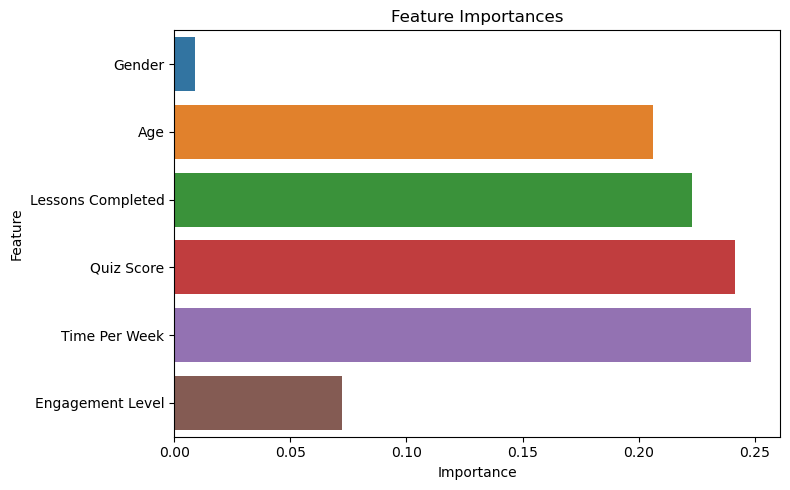

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
